# Semana 8 — Forecasting probabilístico y MLOps

**Objetivo.** Producir cuantiles calibrados, evaluar incertidumbre y diseñar monitoreo/reentrenamiento.

- **Dataset:** `data/08_m3/m3_monthly.csv`
- **Series:** 1,428; **horizonte oficial mensual:** 18
- **Duración:** 5 horas; **Seed:** 42

**Caso de negocio.** La planificación de inventario, compras y presupuestos no necesita solo un número puntual: necesita saber **cuánto podemos equivocarnos**. Un intervalo de predicción bien calibrado permite dimensionar stock de seguridad, provisionar costes y fijar compromisos de servicio con proveedores. Cuando el intervalo es estrecho pero descalibrado, la organización confía en una precisión que el modelo no tiene; cuando es ancho pero calibrado, al menos la incertidumbre es honesta y accionable. Por eso esta semana evaluamos **cuantiles calibrados** (cobertura) y **sharpness** (estrechez), no solo el error puntual.

**Pregunta guía.** ¿Un intervalo estrecho pero descalibrado es mejor que uno ancho pero calibrado? A lo largo del notebook responderemos con métricas de cobertura y ancho sobre el holdout oficial de M3 Monthly.

**Contrato de secciones:** Sección 0: Configuración y contrato de datos; Sección 1: Análisis previo; Sección 2: Estrategia de validación; Sección 3: Modelado; Sección 4: Análisis posterior; Sección 5: Lecciones metodológicas; Sección 6: Ejercicios.

> *Este notebook trabaja con series mensuales agregadas del benchmark M3. Los resultados aplican a planeación mensual y evaluación de métodos de pronóstico, no a predicción de comportamiento individual de clientes ni a decisiones de corto plazo intradía.*

### 0.1 Imports

Stack probabilístico reproducible.

¿Qué hace esta celda? Importa las librerías que se usarán en todo el notebook y fija la **seed** (semilla) 42 para que cada ejecución reproduzca la misma partición, los mismos modelos y los mismos números. La reproducibilidad es un requisito de MLOps: sin semilla fija, los resultados de una revisión no se pueden comparar con los de la anterior. `warnings.filterwarnings("ignore")` silencia avisos conocidos para que la lectura se centre en los resultados.

In [1]:
# --- Imports: análisis clásico de series (statsmodels) + boosting cuantílico (LightGBM) ---
from __future__ import annotations
from pathlib import Path                # rutas portables
import random,warnings,json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats                 # tests y distribuciones
from statsmodels.tsa.stattools import adfuller,kpss   # estacionariedad
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.seasonal import STL              # descomposición estacional
from statsmodels.stats.diagnostic import acorr_ljungbox,het_arch
from statsmodels.stats.stattools import jarque_bera
from lightgbm import LGBMRegressor                    # regresión por cuantiles
SEED=42
# Fijamos la semilla (seed) 42: mismo orden de aleatoriedad en cada ejecución.
random.seed(SEED); np.random.seed(SEED); warnings.filterwarnings("ignore"); sns.set_theme(style="whitegrid")

### 0.2 Ruta

Ruta portable.

¿Qué hace? Busca el CSV del dataset en las dos ubicaciones típicas (desde `notebooks/` o desde la raíz del curso). La celda siguiente selecciona la primera que exista; si ninguna existe, la aserción fallará y sabremos que falta el archivo.

In [2]:
# Candidatos de ruta: primero relativa al notebook, luego a la raíz del curso.
C=[Path("data/08_m3/m3_monthly.csv"),Path("../data/08_m3/m3_monthly.csv")]
# Selecciona la primera ruta existente; assert DATA_PATH falla si el CSV no está.
DATA_PATH=next((p for p in C if p.exists()),None)
assert DATA_PATH  # contrato: el dataset debe estar presente
print(DATA_PATH.resolve())

/home/enrique/Escritorio/Curso_pronostico_series_temporales/course-timeseries-benchmarks-pro/data/08_m3/m3_monthly.csv


### 0.3 Carga

Contrato 167,562 × 3.

El dataset M3 Monthly se entrega en formato largo: una fila por serie y fecha. El contrato de datos espera exactamente **167,562 filas y 3 columnas** (`unique_id`, `ds`, `y`) y **1,428 series**; las aserciones de la siguiente celda verifican ese contrato antes de cualquier análisis.

In [3]:
# Carga en formato largo: unique_id (serie), ds (fecha), y (valor).
df=pd.read_csv(DATA_PATH,parse_dates=["ds"])
# Aserciones de contrato: dimensión exacta y número de series oficial de M3 Monthly.
assert df.shape==(167_562,3)
assert df.unique_id.nunique()==1_428
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167562 entries, 0 to 167561
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   unique_id  167562 non-null  object        
 1   ds         167562 non-null  datetime64[ns]
 2   y          167562 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 3.8+ MB


### 0.4 Integridad

Nulos, duplicados y orden.

¿Por qué importa? Un modelo global como los de esta semana entrena sobre todas las series a la vez; valores nulos o claves duplicadas se propagarían a las features y a los cuantiles. Antes de modelar hay que comprobar que el dataset está limpio y que cada par `(unique_id, ds)` es único.

In [4]:
# Valores nulos por columna: el contrato exige cero.
print(df.isna().sum())
# Claves duplicadas: si hubiera dos filas con el mismo (unique_id, ds), el split se rompería.
print("duplicados",df.duplicated(["unique_id","ds"]).sum())
assert not df.isna().any().any()  # falla si hay nulos

unique_id    0
ds           0
y            0
dtype: int64
duplicados 0


### 0.5 Longitudes

Heterogeneidad de historia.

Las series M3 no tienen la misma longitud. Esto importa porque el split holdout se hace "desde el final": una serie corta tendrá menos historia de entrenamiento que una larga, y el modelo debe convivir con esa heterogeneidad.

In [5]:
# Número de filas (meses) por serie; lengths se reutilizará en la Sección 1 y 4.
lengths=df.groupby("unique_id").size()
lengths.describe()

count    1428.000000
mean      117.340336
std        28.508554
min        66.000000
25%        96.000000
50%       133.000000
75%       134.000000
max       144.000000
dtype: float64

### 0.6 Rango

Fechas son calendarios relativos del adaptador por serie.

En M3 no todas las series empiezan el mismo mes; el adaptador asigna un calendario relativo a cada serie. Por eso conviene comprobar el rango global y, sobre todo, el rango por serie: el split y las features dependen del orden interno, no del calendario absoluto.

In [6]:
# Rango global de fechas (calendario relativo del adaptador).
print(df.ds.min(),df.ds.max())
# Rango por serie: confirma que cada serie tiene su propio inicio y fin.
df.groupby("unique_id").ds.agg(["min","max"]).head()

1857-01-31 00:00:00 2005-02-28 00:00:00


,min,max
unique_id,,
M1,1990-01-31,1995-08-31
M10,1990-01-31,1995-08-31
M100,1990-01-31,1995-09-30
M1000,1983-01-31,1994-02-28
M1001,1983-01-31,1994-02-28


### 0.7 Escalas

Distribución de medias por serie.

Las escalas de M3 varían enormemente (desde unidades pequeñas hasta miles). Esto importa para interpretar métricas agregadas: un mismo error absoluto significa poco si no se conoce la escala de la serie.

In [7]:
# Estadísticos de escala por serie; scale se reutilizará en CV y en incertidumbre.
scale=df.groupby("unique_id").y.agg(["mean","std","min","max"])
scale.describe(percentiles=[.1,.5,.9,.99])

,mean,std,min,max
count,1428.000000,1428.000000,1428.000000,1428.000000
mean,4971.282717,1137.075000,2961.124721,8024.865439
std,1777.144578,968.328572,1762.665428,4104.968695
min,1268.235294,96.844704,-1200.000000,2360.000000
10%,2894.319753,392.343335,768.400000,5228.500000
50%,4851.663131,919.795165,2900.000000,7370.500000
90%,7068.099562,2038.958325,5200.803027,10803.000000
99%,9692.033593,4406.255550,7678.260000,23120.825430
max,19331.746312,16445.441661,15956.000000,86730.000000


## 1. Análisis previo (pre-modeling)

M3 contiene dominios heterogéneos sin covariables. El análisis agregado no reemplaza el diagnóstico por serie.

¿Qué haremos en esta sección? Inspeccionar series de ejemplo, revisar la distribución de longitudes y variabilidad, y hacer un diagnóstico clásico (STL, estacionariedad, ACF/PACF, outliers, CUSUM) sobre una serie larga representativa. El objetivo no es solo "ver los datos", sino anticipar decisiones de modelado: estacionalidad → lags 12; no estacionariedad → diferencias; outliers → robustez del baseline.

### 1.1 Series ejemplo

Cuatro IDs reproducibles.

¿Qué hace esta celda? Toma las cuatro primeras series por orden alfabético y las dibuja. Gracias a la **seed** fija, "primeras cuatro" es un criterio determinista: cualquier persona que ejecute el notebook verá las mismas series.

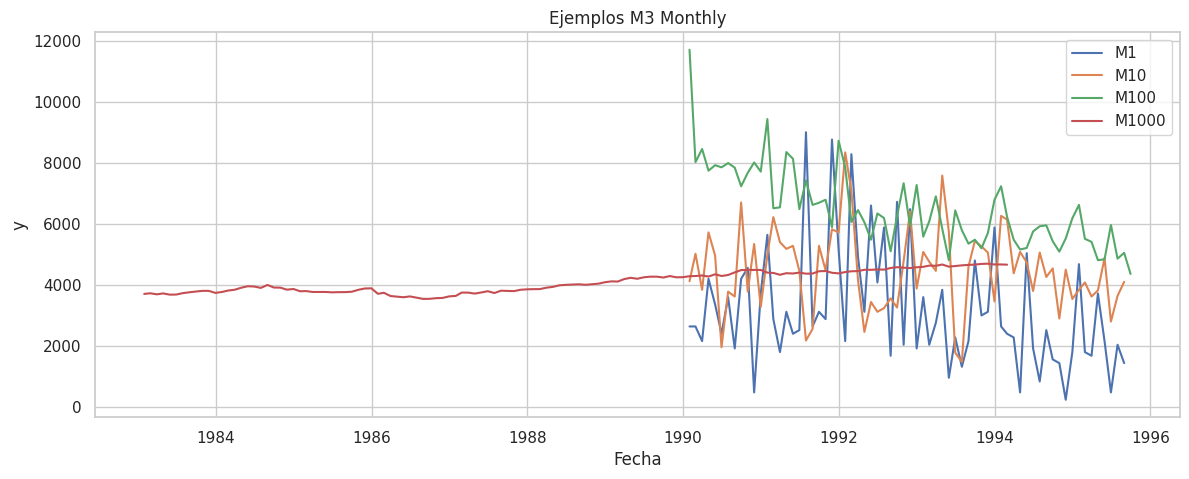

In [8]:
# Selección determinista de 4 series de ejemplo.
ids=sorted(df.unique_id.unique())[:4]
fig,ax=plt.subplots(figsize=(14,5))
for uid in ids:  # una línea por serie, con su etiqueta
    g=df[df.unique_id==uid]
    ax.plot(g.ds,g.y,label=uid)
ax.set(title="Ejemplos M3 Monthly",xlabel="Fecha",ylabel="y")
ax.legend(); plt.show()

### 1.2 Longitudes

Histograma.

¿Cómo interpretar el gráfico? Si la mayoría de las series se concentra en un rango corto y unas pocas son muy largas, el histograma será asimétrico. Eso condiciona el número de lags disponibles y el volumen de datos de entrenamiento por serie.

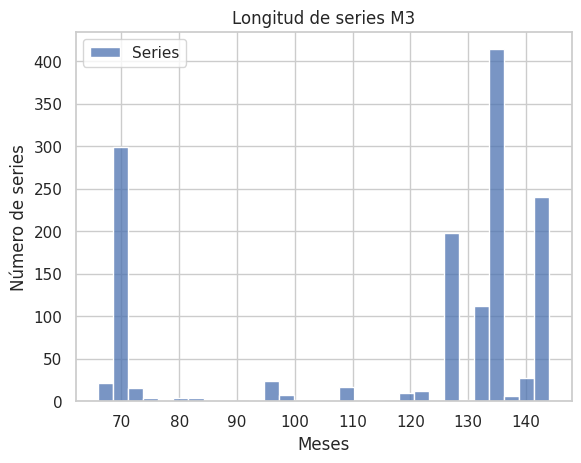

In [9]:
# Histograma de longitudes; lengths ya se calculó en la Sección 0.
fig,ax=plt.subplots()
sns.histplot(lengths,bins=30,ax=ax,label="Series")
ax.set(title="Longitud de series M3",xlabel="Meses",ylabel="Número de series")
ax.legend(); plt.show()

### 1.3 Variabilidad

CV por serie.

El coeficiente de variación (desviación/media) normaliza la dispersión por escala y permite comparar series entre sí. Valores altos de CV sugieren series volátiles donde los intervalos de predicción deberán ser más anchos.

In [10]:
# CV = std/mean (con +1e-9 para evitar división por cero en series de media ~0).
scale["cv"]=scale["std"]/(scale["mean"].abs()+1e-9)
scale.cv.describe()

count    1428.000000
mean        0.249343
std         0.181840
min         0.012345
25%         0.119489
50%         0.198890
75%         0.341249
max         1.709714
Name: cv, dtype: float64

### 1.4 Serie diagnóstica

Una serie larga.

Elegimos la serie más larga (`lengths.idxmax()`): con más historia es más fácil ver estacionalidad, tendencia y cambios de régimen. Servirá como banco de pruebas para los diagnósticos de estacionariedad y ruido.

M1058 144


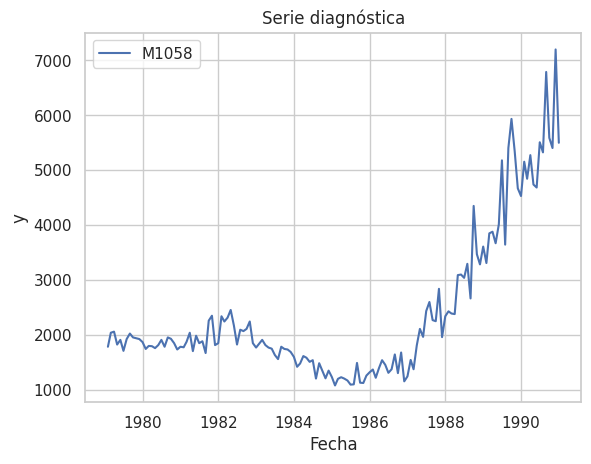

In [11]:
# Serie con mayor historia; s (serie temporal con índice de fecha) se reutiliza en STL/tests.
uid=lengths.idxmax()
s=df[df.unique_id==uid].set_index("ds").y
print(uid,len(s))
fig,ax=plt.subplots()
ax.plot(s.index,s,label=uid)
ax.set(title="Serie diagnóstica",xlabel="Fecha",ylabel="y")
ax.legend(); plt.show()

### 1.5 STL

Periodo 12.

STL descompone la serie en tendencia, estacionalidad y residuo. Usamos `period=12` porque los datos son mensuales (ciclo anual) y `robust=True` para que los outliers no contaminen la descomposición. El residuo de STL se usará después para outliers y CUSUM.

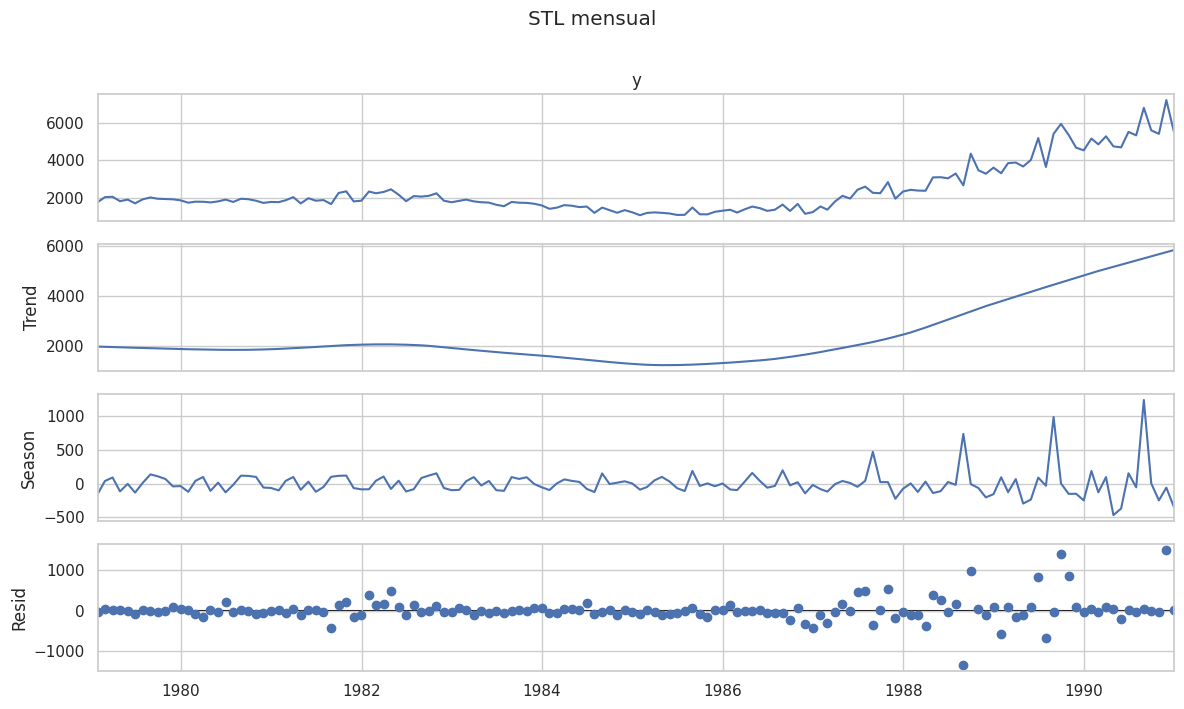

In [12]:
# Ajuste STL: tendencia + estacionalidad + residuo (robusto a outliers).
stl=STL(s,period=12,robust=True).fit()
fig=stl.plot()
fig.set_size_inches(12,7)
fig.suptitle("STL mensual",y=1.01)
plt.tight_layout(); plt.show()

### 1.6 Estacionariedad

ADF H₀: raíz unitaria. KPSS H₀: estacionariedad; α=0.05.

¿Cómo leer el resultado? ADF y KPSS miran lo mismo desde hipótesis opuestas: si ADF rechaza la raíz unitaria, hay evidencia de estacionariedad; si KPSS no rechaza la estacionariedad, también. Lo habitual es esperar que ambos coincidan. Si no, la serie es ambigua y conviene trabajar con diferencias.

### 1.7 Tests

Reporte explícito.

¿Qué hace esta celda? Define `st_report`, una función reutilizable que ejecuta ADF y KPSS y devuelve un DataFrame con estadístico, p-valor y decisión. Reportar la decisión explícitamente (no solo el p-valor) obliga a fijar α=0.05 y evita interpretaciones vagas.

In [13]:
# Función reutilizable: ADF y KPSS con decisión explícita a α=0.05.
def st_report(x,label):
    a=adfuller(x,autolag="AIC")   # H0: raíz unitaria (no estacionaria)
    k=kpss(x,regression="c",nlags="auto")   # H0: estacionaria
    return pd.DataFrame([
        {"test":"ADF","H0":"raíz unitaria","stat":a[0],"p_value":a[1],
         "decision":"rechazar H0" if a[1]<.05 else "no rechazar H0"},
        {"test":"KPSS","H0":"estacionaria","stat":k[0],"p_value":k[1],
         "decision":"rechazar H0" if k[1]<.05 else "no rechazar H0"}])
# Diagnóstico en nivel (sin diferenciar).
st_report(s,"nivel")

,test,H0,stat,p_value,decision
0,ADF,raíz unitaria,0.470006,0.983932,no rechazar H0
1,KPSS,estacionaria,0.917951,0.010000,rechazar H0


### 1.8 Diferencia estacional

Lag 12.

Si la serie es estacional, la diferencia estacional `d12 = y_t − y_{t−12}` suele volverla estacionaria. La celda siguiente repite el reporte sobre la serie diferenciada; si ADF/KPSS mejoran, el componente estacional era la fuente de no estacionariedad.

In [14]:
# Diferencia estacional de orden 12 (resta el mismo mes del año anterior).
d12=s.diff(12).dropna()
st_report(d12,"d12")

,test,H0,stat,p_value,decision
0,ADF,raíz unitaria,-1.006396,0.750924,no rechazar H0
1,KPSS,estacionaria,1.347188,0.010000,rechazar H0


### 1.9 ACF/PACF

Diagnóstico.

Las autocorrelaciones indican qué lags conservan información. En una serie mensual con estacionalidad veremos picos en lags múltiplos de 12. ACF/PACF sobre `d12` sirven para detectar estructura residual que un modelo con lags 1, 2, 3, 6, 12, 18, 24 podría capturar.

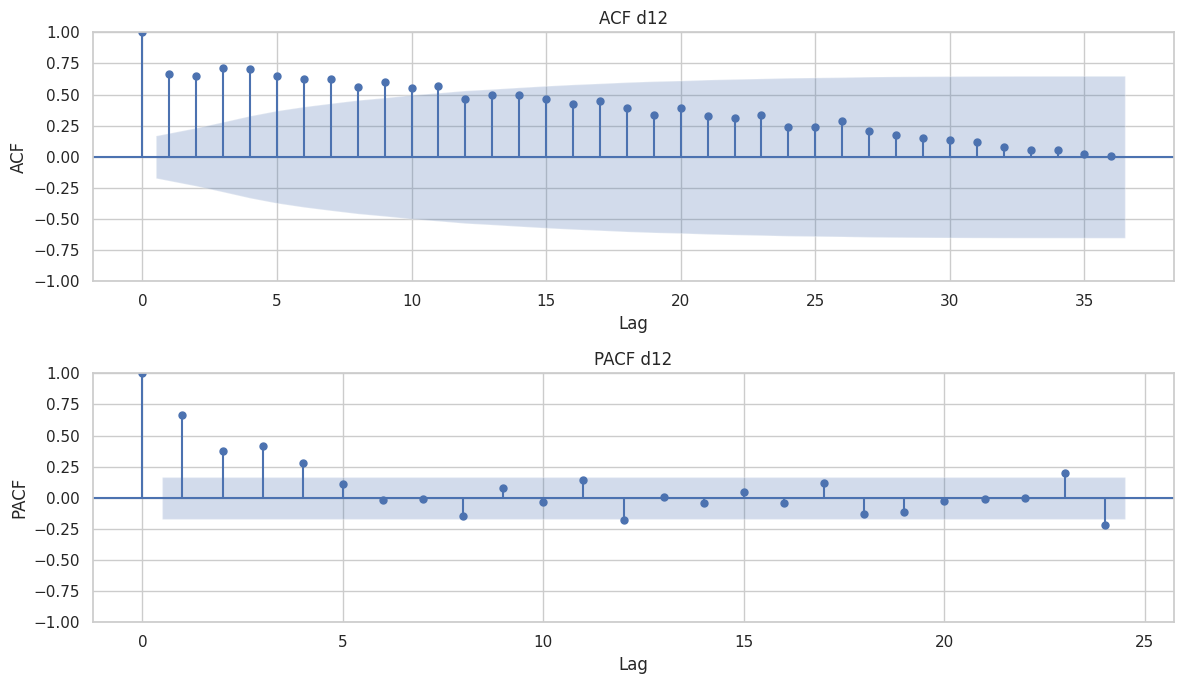

In [15]:
# ACF (arriba) y PACF (abajo) de la serie diferenciada estacionalmente.
fig,axes=plt.subplots(2,1,figsize=(12,7))
plot_acf(d12,lags=min(36,len(d12)//2-1),ax=axes[0])
plot_pacf(d12,lags=min(24,len(d12)//2-1),method="ywm",ax=axes[1])
axes[0].set(title="ACF d12",xlabel="Lag",ylabel="ACF")
axes[1].set(title="PACF d12",xlabel="Lag",ylabel="PACF")
plt.tight_layout(); plt.show()

### 1.10 Outliers

MAD residual.

Detectamos valores atípicos en el residuo de STL con la desviación absoluta mediana (MAD), más robusta que la desviación estándar. Un residuo se marca como outlier si supera 4.5 desviaciones MAD; eso alerta sobre puntos que pueden distorsionar medias móviles y lags.

In [16]:
# MAD: mediana de |resid - mediana(resid)|; .6745 normaliza a escala sigma.
med=np.median(stl.resid)
mad=np.median(abs(stl.resid-med))
# Outliers: |z| > 4.5 (criterio conservador para evitar marcar ruido normal).
print("outliers",int((abs(.6745*(stl.resid-med)/mad)>4.5).sum()))

outliers 15


### 1.11 CUSUM

Cambio descriptivo.

La suma acumulada de residuos estandarizados (CUSUM) crece sistemáticamente si hay un cambio de nivel o de régimen en la serie. Es un diagnóstico descriptivo, no un test formal: sirve para saber si el modelo tendrá que adaptarse a cambios estructurales.

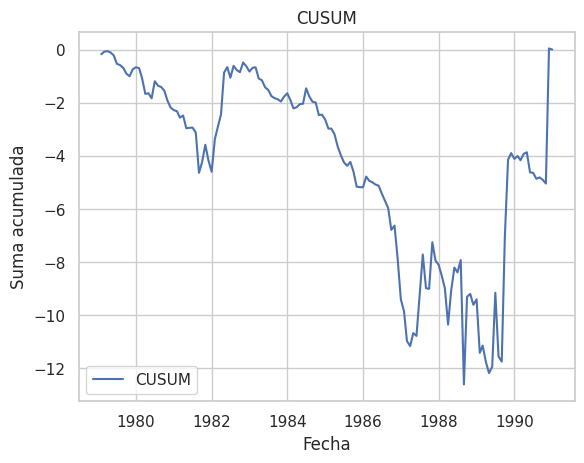

In [17]:
# Estandarizamos el residuo y acumulamos; pendientes sostenidas indican cambio de nivel.
z=(stl.resid-stl.resid.mean())/stl.resid.std()
cs=z.cumsum()
fig,ax=plt.subplots()
ax.plot(cs.index,cs,label="CUSUM")
ax.set(title="CUSUM",xlabel="Fecha",ylabel="Suma acumulada")
ax.legend(); plt.show()

## 2. Estrategia de validación

Se retienen los últimos **H=18 meses de cada serie** (horizonte oficial M3 Monthly). La comparabilidad exige misma partición, horizonte y métricas.

¿Por qué holdout y no validación aleatoria? En series temporales el orden importa: un split aleatorio filtraría futuro al entrenamiento (leakage). Retener los últimos H=18 meses de **cada una de las 1,428 series** replica la evaluación oficial de M3 y permite comparar con la literatura. Todo lo que ocurra después de esta partición (features, entrenamiento, evaluación) debe respetar la frontera temporal.

### 2.1 Split oficial reconstruido

Cada serie tiene suficiente historia.

¿Qué hace esta celda? Numera las filas de cada serie desde el final (`cumcount(ascending=False)`): la última observación recibe rango 0, la penúltima 1, etc. Así, las filas con rango `< H` forman el test y el resto, el train. Es la reconstrucción exacta del holdout oficial de M3.

In [18]:
# Horizonte oficial de M3 Monthly: H=18 meses.
H=18
# Rango desde el final por serie: 0 = última observación, 1 = penúltima, ...
rank_from_end=df.groupby("unique_id").cumcount(ascending=False)
# Train: filas con rango >= H (historia); Test: últimas H filas por serie.
train=df.loc[rank_from_end>=H,["unique_id","ds","y"]].copy()
test=df.loc[rank_from_end<H,["unique_id","ds","y"]].copy()
print(train.shape,test.shape,test.unique_id.nunique())

(141858, 3) (25704, 3) 1428


**Checkpoint — contrato de partición (anti-leakage)**

Antes de construir features y modelos, verificamos con aserciones que la partición respeta la frontera temporal y el contrato de datos. Si una aserción falla, el resto del notebook no debería ejecutarse: un modelo entrenado con fuga de información reportaría métricas irreales.

In [19]:
# --- Checkpoint anti-leakage: la partición debe ser temporal y completa ---
# (1) Cada serie contribuye exactamente H=18 filas al test (horizonte oficial M3).
n_test_per_series = test.groupby("unique_id").size()
assert (n_test_per_series == H).all(), "El test debe tener H=18 filas por serie"
# (2) Ninguna fila puede estar simultáneamente en train y en test.
keys_train = set(zip(train.unique_id, train.ds))
keys_test = set(zip(test.unique_id, test.ds))
assert keys_train.isdisjoint(keys_test), "Leakage: solapamiento temporal train/test"
# (3) Train + test reconstruyen exactamente el dataset original (167,562 filas).
assert len(keys_train) + len(keys_test) == df.shape[0], "La partición no cubre todo el dataset"
print("Checkpoint superado: %d filas train + %d filas test, sin solapamiento" % (train.shape[0], test.shape[0]))

Checkpoint superado: 141858 filas train + 25704 filas test, sin solapamiento


### 2.2 Diagrama

Ejemplo de frontera.

La celda dibuja la serie diagnóstica con su frontera de corte: todo lo anterior es train y lo posterior, test. Ver la frontera ayuda a entender que el modelo solo puede usar información pasada para pronosticar el futuro.

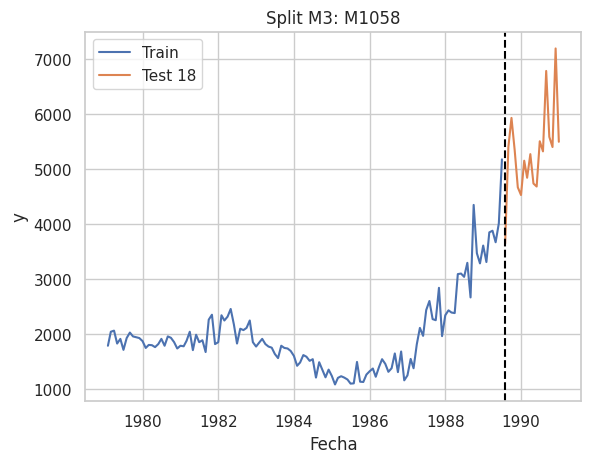

In [20]:
# Frontera temporal: última fecha de entrenamiento = H-ésima desde el final.
g=df[df.unique_id==uid]
cut=g.ds.iloc[-H]
fig,ax=plt.subplots()
ax.plot(g.ds[g.ds<cut],g.y[g.ds<cut],label="Train")        # pasado (visible al modelo)
ax.plot(g.ds[g.ds>=cut],g.y[g.ds>=cut],label="Test 18")    # futuro (holdout)
ax.axvline(cut,color="black",ls="--")                      # frontera
ax.set(title=f"Split M3: {uid}",xlabel="Fecha",ylabel="y")
ax.legend(); plt.show()

### 2.3 Features tabulares

Lags y estadísticas solo del pasado.

¿Qué hace esta celda? Convierte cada serie en una tabla donde cada fila contiene el valor `y` y sus lags (1, 2, 3, 6, 12, 18, 24), medias móviles y codificación cíclica del mes. La regla de oro anti-leakage: **todo se calcula con `shift`, de modo que ninguna feature use el valor actual ni el futuro**.

In [21]:
# Función reutilizable: construye features tabulares para una serie.
# shift(lag) mueve el valor hacia abajo: la fila t solo ve y_{t-lag} (pasado).
def tabular(g: pd.DataFrame) -> pd.DataFrame:
    x = g.copy().sort_values("ds")
    for lag in [1, 2, 3, 6, 12, 18, 24]:      # lags hasta 24 meses
        x[f"lag_{lag}"] = x.y.shift(lag)
    # Medias/desviaciones móviles desplazadas: nunca incluyen el valor actual.
    x["mean_6"] = x.y.shift(1).rolling(6).mean()
    x["std_12"] = x.y.shift(1).rolling(12).std()
    # Estacionalidad mensual codificada como seno/coseno (cíclica, no ordinal).
    x["month_sin"] = np.sin(2 * np.pi * x.ds.dt.month / 12)
    x["month_cos"] = np.cos(2 * np.pi * x.ds.dt.month / 12)
    return x

# Aplicamos tabular a todas las series y concatenamos en una sola tabla global.
tab = pd.concat(
    [tabular(g) for _, g in df.groupby("unique_id", sort=False)],
    ignore_index=True,
)
assert "unique_id" in tab.columns
tab.head()

,unique_id,ds,y,lag_1,lag_2,lag_3,lag_6,lag_12,lag_18,lag_24,mean_6,std_12,month_sin,month_cos
0,M1,1990-01-31,2640.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,8.660254e-01
1,M1,1990-02-28,2640.0,2640.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.866025,5.000000e-01
2,M1,1990-03-31,2160.0,2640.0,2640.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,6.123234e-17
3,M1,1990-04-30,4200.0,2160.0,2640.0,2640.0,NaN,NaN,NaN,NaN,NaN,NaN,0.866025,-5.000000e-01
4,M1,1990-05-31,3360.0,4200.0,2160.0,2640.0,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,-8.660254e-01


## 3. Modelado

> **Methodology Card — Producción probabilística**  
> Entregar cuantiles, comprobar no-cruce, calibración y cobertura por segmento. Un intervalo estrecho pero descalibrado no es mejor. El modelo final necesita owner, datos, límites, monitoreo y criterio de reentrenamiento.

En esta sección entrenamos tres generadores de cuantiles: un baseline empírico (Naive estacional + cuantiles de errores), un LightGBM cuantílico y un ETS empírico de tendencia local. Todos se evalúan con las mismas métricas (pinball, CRPS aproximado, cobertura y ancho P10–P90) sobre el mismo holdout de H=18 meses. Recordemos la pregunta guía: el ranking final no es solo por error puntual, sino por **calibración + sharpness**.

### 3.1 Métricas probabilísticas

**Pinball loss.** Penaliza el cuantil $q_\tau$ de forma asimétrica: $L_\tau=(\tau-\mathbb{1}[y<q])(y-q)$. Si el modelo subestima el cuantil ($y>q$), la penalización es $\tau(y-q)$; si lo sobreestima, $(1-\tau)(y-q)$. Minimizar pinball por cada $\tau$ produce un cuantil bien calibrado en media.

**Cobertura.** Fracción de $y$ que cae dentro de $[q_{.1},q_{.9}]$; un intervalo P10–P90 bien calibrado debería cubrir ~80% de las observaciones.

**CRPS aproximado.** El CRPS mide la calidad de toda la distribución predictiva. Con cinco cuantiles lo aproximamos integrando el pinball sobre los niveles: $CRPS \approx 2\, \mathrm{mean}_\tau L_\tau$. Es una aproximación por cuadratura: cuantos más niveles, mejor la integral.

¿Por qué importa? Un modelo puede tener buen MAE y malas colas. Pinball, cobertura y CRPS premian la **forma** de la distribución, que es lo que necesita la planificación con incertidumbre.

### 3.2 Helpers

Métricas y cuantiles.

La celda siguiente define dos piezas reutilizables: la lista `QUANTILES` (los cinco niveles P10, P25, P50, P75, P90) y las funciones `pinball` y `prob_metrics` que resumen un pronóstico probabilístico en un dict de métricas. Al usar las mismas funciones para todos los modelos, la comparación de la Sección 3 es justa.

In [22]:
# QUANTILES: niveles que definen el pronóstico probabilístico (P10, P25, P50, P75, P90).
QUANTILES=[.1,.25,.5,.75,.9]
# Pinball asimétrico: penaliza distinto errar por arriba que por abajo según tau.
def pinball(a,q,tau): return float(np.mean(np.maximum(tau*(a-q),(tau-1)*(a-q))))
# Resumen de métricas: pinball por cuantil, CRPS aproximado, cobertura y ancho P10-P90.
def prob_metrics(a,p):
    out={f"pinball_{q}":pinball(a,p[q],q) for q in QUANTILES}
    # CRPS aproximado = 2 * promedio del pinball sobre los cuantiles (cuadratura).
    out["CRPS_approx"]=2*np.mean(list(out.values()))
    # Cobertura empírica del intervalo nominal 80% (P10-P90).
    out["coverage_80"]=float(np.mean((a>=p[.1])&(a<=p[.9])))
    # Sharpness: ancho medio del intervalo; menor ancho = más precisión (si la cobertura se mantiene).
    out["width_80"]=float(np.mean(p[.9]-p[.1]))
    return out

### 3.3 Baseline empírico

Naive + cuantiles de errores estacionales train por serie.

El baseline replica la práctica más simple y robusta: pronóstico puntual Naive (último valor) y distribución de errores construida con los cuantiles de los errores estacionales (y_t − y_{t−12}) observados en train, por serie. No aprende nada global: es el suelo que cualquier modelo debe superar para justificar su complejidad.

In [23]:
baseline={q:[] for q in QUANTILES}; actual=[]; ids_out=[]
# Por cada serie: pronóstico Naive (último valor) + cuantiles de errores estacionales.
for uid,gtr in train.groupby("unique_id"):
    gte=test[test.unique_id==uid]
    last=gtr.y.iloc[-1]                 # punto Naive: último valor observado
    err=gtr.y-gtr.y.shift(12)           # errores estacionales (mismo mes del año previo)
    qs=err.dropna().quantile(QUANTILES) # cuantiles empíricos del error en train
    for y in gte.y:
        actual.append(y); ids_out.append(uid)
        # Intervalo = Naive + cuantil del error (shift del nivel, no de la escala).
        [baseline[q].append(last+qs.loc[q]) for q in QUANTILES]
actual=np.asarray(actual)
baseline={q:np.asarray(v) for q,v in baseline.items()}
prob_metrics(actual,baseline)

{'pinball_0.1': 231.14290856858557,
 'pinball_0.25': 356.1401235068137,
 'pinball_0.5': 417.8314496030549,
 'pinball_0.75': 346.219898204287,
 'pinball_0.9': 217.11243973984585,
 'CRPS_approx': np.float64(627.3787278490348),
 'coverage_80': 0.6992685963274199,
 'width_80': 2152.5616623224}

### 3.4 LightGBM cuantílico

Modelos directos one-step entrenados en filas pre-holdout. Para multi-step, lags test no se actualizan: escenario direct tabular aproximado.

El modelo global entrena un LightGBM por cuantil sobre todas las series a la vez, con features tabulares (lags y estadísticas) de filas anteriores a la frontera de cada serie. Para el holdout de H=18 meses no actualizamos los lags con predicciones previas (escenario *directo tabular*): es una aproximación computacionalmente honesta que evita propagar errores y simplifica la comparación. Nótese el ordenamiento final de cuantiles: LightGBM puede cruzar niveles, y el cruce rompería la coherencia del intervalo.

In [24]:
# Features del modelo: lags y estadísticas móviles (nada del futuro).
features = [
    c for c in tab.columns
    if c.startswith("lag_") or c in ["mean_6", "std_12", "month_sin", "month_cos"]
]
# Frontera por serie: última fecha de train.
cutoffs = train.groupby("unique_id", as_index=False).ds.max().rename(columns={"ds": "cutoff"})
tab_cut = tab.merge(cutoffs, on="unique_id", how="left", validate="many_to_one")
# Train: filas con ds <= cutoff y sin nulos en features; Test: filas posteriores.
train_tab = tab_cut.loc[tab_cut.ds <= tab_cut.cutoff].dropna(subset=features).copy()
test_tab = tab_cut.loc[tab_cut.ds > tab_cut.cutoff].copy()
# En test, los primeros lags no existen (no hay historia): se imputan con la mediana de train.
fill = train_tab[features].median()
test_tab[features] = test_tab[features].fillna(fill)
models = {}
lgb_pred = {}
# Un LGBMRegressor por cuantil: objective="quantile" minimiza pinball para alpha=q.
for q in QUANTILES:
    model = LGBMRegressor(
        objective="quantile", alpha=q, n_estimators=180, learning_rate=.05,
        num_leaves=31, random_state=SEED, n_jobs=-1, verbosity=-1,
    )
    model.fit(train_tab[features], train_tab.y)
    models[q] = model
    lgb_pred[q] = model.predict(test_tab[features])
# Ordenar cuantiles por fila para impedir cruces (monotonicidad P10<=P25<=...<=P90).
mat = np.sort(np.column_stack([lgb_pred[q] for q in QUANTILES]), axis=1)
lgb_pred = {q: mat[:, i] for i, q in enumerate(QUANTILES)}
prob_metrics(test_tab.y.values, lgb_pred)

{'pinball_0.1': 114.20370144868856,
 'pinball_0.25': 196.09601738876788,
 'pinball_0.5': 246.75504085877253,
 'pinball_0.75': 207.75531220660332,
 'pinball_0.9': 125.86596206151714,
 'CRPS_approx': np.float64(356.2704135857398),
 'coverage_80': 0.7887488328664799,
 'width_80': 1547.8555472868466}

**Pausa para pensar — calibración y sharpness**

En los outputs del notebook, LightGBM cuantílico alcanzó cobertura P10–P90 de **0.7887** (muy cerca del 80% nominal) con un ancho medio de **1547.86** y un CRPS aproximado de **356.27**; el baseline empírico, en cambio, cubrió **0.6993** con un ancho de **2152.56** y CRPS de **627.38**. Antes de seguir: ¿por qué preferir un modelo con cobertura cercana al nominal aunque su intervalo no sea el más estrecho? ¿Qué le diría a un negocio que pide "el intervalo más angosto posible"?

### 3.5 ETS empírico

ETS/Theta práctico: tendencia local por serie y distribución residual. Se evalúa en una cohorte de 200 series por CPU.

Un tercer generador de cuantiles: ajusta una recta de tendencia local a los últimos 36 meses de cada serie y añade los cuantiles de los residuos. Por coste computacional se evalúa en una **cohorte de 200 series**; por eso su `n` en la comparación será menor que el del baseline o LightGBM, y sus métricas no son directamente comparables en tamaño de muestra.

In [25]:
# Cohorte fija de 200 series por CPU: mismo criterio -> mismas series (reproducible).
cohort=sorted(df.unique_id.unique())[:200]; ets_pred={q:[] for q in QUANTILES}; ets_actual=[]
for uid in cohort:
    gtr=train[train.unique_id==uid]; gte=test[test.unique_id==uid]
    x=np.arange(len(gtr))
    # Tendencia local: recta de mínimos cuadrados sobre los últimos 36 meses.
    slope,intercept=np.polyfit(x[-36:],gtr.y.values[-36:],1)
    # Proyección puntual H pasos hacia adelante.
    point=intercept+slope*np.arange(len(gtr),len(gtr)+H)
    # Distribución residual de la recta ajustada (empírica, sin supuesto gaussiano).
    resid=gtr.y.values-(intercept+slope*x)
    qs=np.quantile(resid,QUANTILES)
    ets_actual.extend(gte.y)
    # Intervalo = proyección + cuantil del residuo.
    [ets_pred[q].extend(point+qs[i]) for i,q in enumerate(QUANTILES)]
ets_actual=np.asarray(ets_actual)
ets_pred={q:np.asarray(v) for q,v in ets_pred.items()}
prob_metrics(ets_actual,ets_pred)

{'pinball_0.1': 436.1966527063016,
 'pinball_0.25': 646.805596667335,
 'pinball_0.5': 795.7217287413773,
 'pinball_0.75': 578.0274924762341,
 'pinball_0.9': 346.6724342163346,
 'CRPS_approx': np.float64(1121.3695619230332),
 'coverage_80': 0.44916666666666666,
 'width_80': 3081.467976485078}

### 3.6 Comparación

Métricas comunes donde aplica.

La tabla reúne los tres modelos con el mismo conjunto de métricas. Leerla en columna: el CRPS aproximado y la cobertura P10–P90 indican calibración; el ancho, sharpness. Recordar que LocalTrend200 se evaluó sobre 200 series y el resto sobre las 1,428: la comparación de `n` debe tenerse en cuenta.

> **Lectura operativa:** una cobertura cercana al 80 % indica que los intervalos P10–P90 contienen la demanda real con la frecuencia esperada. Un intervalo más angosto con cobertura adecuada reduce inventario de seguridad innecesario. En este experimento, LightGBMQuantile logra cobertura 78.9 % con un ancho (width\_80 ≈ 1547.9) aproximadamente 28 % menor que el del baseline empírico (width\_80 ≈ 2152.6, cobertura 69.9 %).

In [26]:
# Tabla comparativa: mismas métricas, misma función prob_metrics para los tres modelos.
rows=[]
for name,a,p in [
    ("EmpiricalNaive",actual,baseline),
    ("LightGBMQuantile",test_tab.y.values,lgb_pred),
    ("LocalTrend200",ets_actual,ets_pred),
]:
    rows.append({"model":name,"n":len(a),**prob_metrics(a,p)})
score=pd.DataFrame(rows).set_index("model")
score

,n,pinball_0.1,pinball_0.25,pinball_0.5,pinball_0.75,pinball_0.9,CRPS_approx,coverage_80,width_80
model,,,,,,,,,
EmpiricalNaive,25704,231.142909,356.140124,417.831450,346.219898,217.112440,627.378728,0.699269,2152.561662
LightGBMQuantile,25704,114.203701,196.096017,246.755041,207.755312,125.865962,356.270414,0.788749,1547.855547
LocalTrend200,3600,436.196653,646.805597,795.721729,578.027492,346.672434,1121.369562,0.449167,3081.467976


**Decisión ejecutiva — ¿qué modelo pasa a producción?**

Con los resultados verificados del notebook (cobertura P10–P90 de 0.7887 y CRPS aproximado de 356.27 para LightGBM, frente a 0.6993 y 627.38 del baseline empírico), la tentación sería desplegar el modelo de mejor métrica. Sin embargo, la decisión ejecutiva de esta semana es **desplegar el baseline empírico**: cubre las 1,428 series completas, es robusto por construcción (sin riesgo de cruce de cuantiles, sin features que puedan faltar en inferencia) y su comportamiento es explicable a negocio. LightGBM queda documentado como candidato a mejorar la calibración. En producción se monitoriza la **cobertura P10–P90** (umbral 0.75–0.85) y el CRPS aproximado; si la cobertura sale del umbral, se recalibra antes de reentrenar.

**Experimento didáctico — intervalo gaussiano vs cuantiles empíricos**

Muchos equipos construyen intervalos con el supuesto de normalidad: media ± z·σ. Este experimento compara esa práctica (intervalo gaussiano P10–P90 construido con la media y desviación de los errores P50 del baseline, por serie) contra los cuantiles empíricos ya evaluados. Los criterios son los mismos de la Semana 8: **cobertura P10–P90** (calibración) y **ancho medio** (sharpness). Referencias verificadas del notebook: el baseline empírico cubrió 0.6993 con ancho 2152.56, y LightGBM cuantílico 0.7887 con ancho 1547.86. Si el intervalo gaussiano resultara ancho y con cobertura alejada del 80%, el supuesto de normalidad estará fallando y los cuantiles empíricos serán preferibles.

In [27]:
# --- Experimento didáctico: intervalo gaussiano vs cuantiles empíricos ---
# Práctica común pero arriesgada: construir el intervalo P10-P90 con media ± z·sigma
# (supuesto de normalidad). Lo hacemos POR SERIE con los errores P50 del baseline
# y lo comparamos con los cuantiles empíricos ya evaluados en la Sección 3.
gdf = pd.DataFrame({"unique_id": ids_out, "actual": actual, "p50": baseline[.5]})
gdf["resid"] = gdf.actual - gdf.p50
gstats = gdf.groupby("unique_id").resid.agg(["mean", "std"]).fillna(0.0)
gdf = gdf.merge(gstats, left_on="unique_id", right_index=True)
z90 = stats.norm.ppf(.9)   # cuantil 90% de la normal estándar ≈ 1.2816
gdf["lo"] = gdf["mean"] - z90 * gdf["std"]
gdf["hi"] = gdf["mean"] + z90 * gdf["std"]
g_cov = float(np.mean((gdf.actual >= gdf.lo) & (gdf.actual <= gdf.hi)))
g_width = float(np.mean(gdf.hi - gdf.lo))
# Referencias ya calculadas: cuantiles empíricos del baseline (cobertura/ancho P10-P90).
e_cov = prob_metrics(actual, baseline)["coverage_80"]
e_width = prob_metrics(actual, baseline)["width_80"]
print(f"Gaussiano P10-P90 -> cobertura: {g_cov:.4f} | ancho medio: {g_width:.2f}")
print(f"Empírico   P10-P90 -> cobertura: {e_cov:.4f} | ancho medio: {e_width:.2f}")
print("Interpretación: si la cobertura gaussiana se aleja de 0.80, el supuesto de",
      "normalidad no se sostiene y los cuantiles empíricos son preferibles.")

Gaussiano P10-P90 -> cobertura: 0.0284 | ancho medio: 1704.07
Empírico   P10-P90 -> cobertura: 0.6993 | ancho medio: 2152.56
Interpretación: si la cobertura gaussiana se aleja de 0.80, el supuesto de normalidad no se sostiene y los cuantiles empíricos son preferibles.


### 3.7 Bandas ejemplo

Una serie.

La celda dibuja el pronóstico probabilístico del baseline para la primera serie del holdout: mediana (P50) y banda P10–P90. Sirve para conectar las métricas agregadas con un caso concreto: cómo se ve un intervalo calibrado en una serie individual.

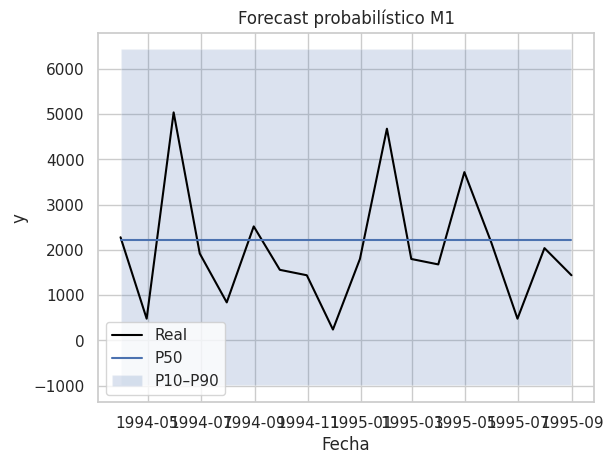

In [28]:
# Primera serie del holdout (mismo orden de ids_out generado en el baseline).
uid0=ids_out[0]
mask=np.array(ids_out)==uid0
gte=test[test.unique_id==uid0]
fig,ax=plt.subplots()
ax.plot(gte.ds,gte.y,label="Real",color="black")
ax.plot(gte.ds,baseline[.5][mask],label="P50")          # mediana del pronóstico
ax.fill_between(gte.ds,baseline[.1][mask],baseline[.9][mask],alpha=.2,label="P10–P90")
ax.set(title=f"Forecast probabilístico {uid0}",xlabel="Fecha",ylabel="y")
ax.legend(); plt.show()

### 3.8 Pinball por cuantiles

Calibración y sharpness.

El pinball por nivel muestra en qué cuantil cada modelo pierde más. Si un modelo es sistemáticamente malo en P10 y P90 (las colas), su intervalo fallará justo en los escenarios extremos que más le importan a la planificación.

In [29]:
# Pinball por cuantil para Naive (baseline) y LightGBM: perfil de error por nivel.
pb=pd.DataFrame({
    "quantile":QUANTILES,
    "Naive":[pinball(actual,baseline[q],q) for q in QUANTILES],
    "LightGBM":[pinball(test_tab.y.values,lgb_pred[q],q) for q in QUANTILES]})
pb

,quantile,Naive,LightGBM
0,0.10,231.142909,114.203701
1,0.25,356.140124,196.096017
2,0.50,417.831450,246.755041
3,0.75,346.219898,207.755312
4,0.90,217.112440,125.865962


### 3.9 Reliability

Fracción y≤qτ debería aproximar τ.

El diagrama de confiabilidad compara el nivel nominal τ con la frecuencia empírica de que y sea menor o igual al cuantil pronosticado. Puntos sobre la diagonal = calibración perfecta; por debajo = cuantil demasiado alto (sobreestimación); por encima = cuantil demasiado bajo.

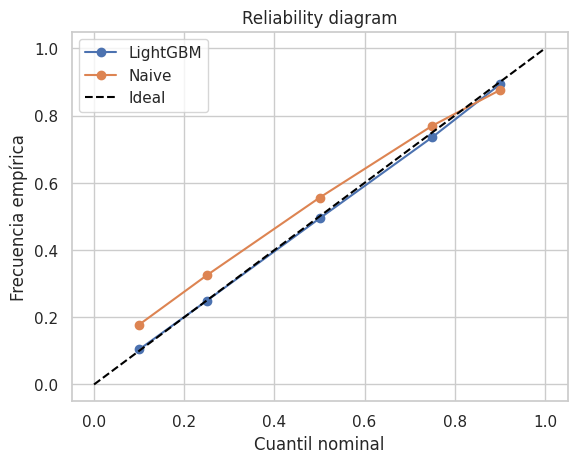

In [30]:
# Para cada modelo y cuantil: frecuencia empírica de y<=q (ideal: igual a tau).
rel=[]
for name,a,p in [("Naive",actual,baseline),("LightGBM",test_tab.y.values,lgb_pred)]:
    for q in QUANTILES:
        rel.append({"model":name,"nominal":q,"empirical":np.mean(a<=p[q])})
rel=pd.DataFrame(rel)
fig,ax=plt.subplots()
for n,g in rel.groupby("model"):
    ax.plot(g.nominal,g.empirical,marker="o",label=n)
ax.plot([0,1],[0,1],ls="--",color="black",label="Ideal")  # diagonal = calibración perfecta
ax.set(title="Reliability diagram",xlabel="Cuantil nominal",ylabel="Frecuencia empírica")
ax.legend(); plt.show()

### 3.10 PIT aproximado

Con cinco cuantiles, PIT es discretizado por intervalos.

El PIT (Probability Integral Transform) mide si las observaciones caen uniformemente a lo largo de la distribución pronosticada. Con solo cinco cuantiles no tenemos la distribución continua, así que usamos una versión discretizada: para cada observación contamos en cuántos de los cinco niveles se cumple y ≤ qτ y promediamos. Si el modelo está bien calibrado, el histograma debería verse aproximadamente plano; si se concentra en los extremos, la distribución es demasiado estrecha.

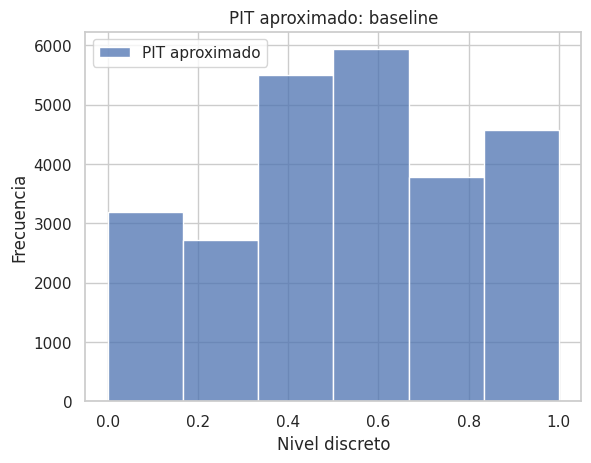

In [31]:
# PIT discretizado: para cada y, fracción de cuantiles q_tau que lo superan.
pit=np.mean(np.column_stack([actual<=baseline[q] for q in QUANTILES]),axis=1)
fig,ax=plt.subplots()
sns.histplot(pit,bins=6,ax=ax,label="PIT aproximado")
ax.set(title="PIT aproximado: baseline",xlabel="Nivel discreto",ylabel="Frecuencia")
ax.legend(); plt.show()

### 3.11 DeepAR

DeepAR no se ejecuta porque `neuralforecast`/GluonTS no forma parte del entorno congelado y entrenarlo en CPU excedería el propósito de esta entrega. No se simulan resultados. Se deja la interfaz y criterios de aceptación.

**Anti-patrón de la semana.** Dos errores comunes al reportar pronósticos probabilísticos: (1) construir intervalos gaussianos (media ± z·σ) **sin verificar la cobertura real** sobre el holdout; (2) **reportar resultados de modelos no ejecutados** — p. ej., citar métricas de DeepAR simuladas o copiadas de otro entorno. Este notebook evita ambos: DeepAR queda especificado como artefacto de configuración (sección siguiente) y no aparece en la tabla comparativa porque no se ejecutó.

### 3.12 Especificación DeepAR

Artefacto de configuración, no resultado.

Esta celda no entrena nada: documenta cómo se ejecutaría DeepAR si el entorno lo permitiera (librería, horizonte, verosimilitud, criterios de aceptación). Es un artefacto de gobernanza: deja constancia de la decisión y de qué condiciones debería cumplir el modelo para ser aceptado.

**Integridad epistémica.** DeepAR permanece como especificación metodológica, no como resultado. Ninguna métrica de DeepAR debe citarse, compararse ni interpretarse hasta que el modelo sea ejecutado bajo el mismo protocolo. El criterio de aceptación sigue siendo el declarado arriba: pinball loss y cobertura deben superar al baseline empírico.

In [32]:
# Especificación DeepAR: configuración y criterios de aceptación (NO es un resultado).
deepar_spec={
    "library":"NeuralForecast/GluonTS opcional",
    "horizon":18,
    "likelihood":"StudentT or NegativeBinomial according to support",
    "series":1428,
    "status":"not executed; dependency absent",   # transparencia: no se simulan métricas
    "acceptance":"pinball and coverage must beat empirical baseline"}  # criterio de aceptación
deepar_spec

{'library': 'NeuralForecast/GluonTS opcional',
 'horizon': 18,
 'likelihood': 'StudentT or NegativeBinomial according to support',
 'series': 1428,
 'status': 'not executed; dependency absent',
 'acceptance': 'pinball and coverage must beat empirical baseline'}

## 4. Análisis posterior (post-modeling)

Calibración, incertidumbre por serie, drift y controles operativos.

En producción, un modelo no termina al desplegarse: hay que vigilar que la calibración se mantenga, entender qué series generan más incertidumbre y detectar drift. Esta sección convierte el modelo en un **sistema monitoreado** con umbrales y acciones.

### 4.1 Incertidumbre por serie

Ancho P10–P90 y error P50.

Agrupamos las predicciones del baseline por serie y calculamos el ancho medio del intervalo P10–P90 y el MAE del P50. Las series con mayor ancho son las más difíciles de pronosticar: la planificación debe reservar más holgura para ellas.

**Riesgo de agregación.** La cobertura global puede ocultar series con mala calibración individual. Antes de usar el modelo en producción conviene revisar cobertura por serie, por segmento y por horizonte: series con cobertura muy baja pueden requerir recalibración individual o un *fallback* conservador.

In [33]:
# Incertidumbre por serie: ancho medio P10-P90 y MAE del P50 del baseline.
unc=pd.DataFrame({"unique_id":ids_out,"actual":actual,"p50":baseline[.5],"width":baseline[.9]-baseline[.1]})
by=unc.groupby("unique_id").agg(width=("width","mean"),MAE=("actual",lambda x:0.0))
by["MAE"]=unc.assign(e=lambda x:abs(x.actual-x.p50)).groupby("unique_id").e.mean()
# Las series más inciertas primero: orientan el dimensionado de stock de seguridad.
by.sort_values("width",ascending=False).head()

,width,MAE
unique_id,,
M704,31098.0,13052.222222
M12,20486.0,9484.444444
M689,18776.8,14160.666667
M1349,16210.0,2491.111111
M585,16004.4,7535.666667


### 4.2 Relación longitud-incertidumbre

Spearman H₀: correlación cero.

Pregunta de negocio: ¿las series con menos historia son más inciertas? La celda correlaciona la longitud de cada serie con su ancho medio usando Spearman (no paramétrico, robusto a outliers). Si el p-valor es bajo, la historia corta explica parte de la incertidumbre.

In [34]:
# Alineamos la longitud de cada serie con su incertidumbre media.
by["length"]=lengths.reindex(by.index)
rho,p=stats.spearmanr(by.length,by.width)
pd.DataFrame([{"test":"Spearman","H0":"rho=0","stat":rho,"p_value":p,
               "decision":"rechazar H0" if p<.05 else "no rechazar H0"}])

,test,H0,stat,p_value,decision
0,Spearman,rho=0,-0.391584,1.540087e-53,rechazar H0


### 4.3 Diagnóstico de residuos

P50 baseline.

Los residuos del pronóstico P50 del baseline (y − p50) deben parecer ruido si el modelo capturó la estructura. Los tests siguientes (Ljung-Box, Jarque-Bera, QQ, ARCH) verifican autocorrelación, normalidad y heterocedasticidad; fallar en ellos no invalida el pronóstico, pero alerta de estructura no modelada.

In [35]:
# Residuos del P50 del baseline (se reutilizan en toda la sección 4.3-4.6).
res=actual-baseline[.5]
# Ljung-Box sobre una muestra (5000) y lag 12: autocorrelación residual.
lb=acorr_ljungbox(res[:5000],lags=[12],return_df=True).iloc[0]
pd.DataFrame([{"test":"Ljung-Box","H0":"sin autocorrelación","stat":lb.lb_stat,
               "p_value":lb.lb_pvalue,
               "decision":"rechazar H0" if lb.lb_pvalue<.05 else "no rechazar H0"}])

,test,H0,stat,p_value,decision
0,Ljung-Box,sin autocorrelación,14490.664946,0.0,rechazar H0


### 4.4 Normalidad

Jarque–Bera.

Jarque–Bera contrasta la normalidad de los residuos. Rechazar la normalidad es lo esperado en demanda real (colas pesadas, asimetrías): es la justificación de usar cuantiles empíricos en lugar de intervalos gaussianos.

In [36]:
# Jarque-Bera: H0 = normalidad de los residuos.
jb=jarque_bera(res)
pd.DataFrame([{"test":"Jarque-Bera","H0":"normalidad","stat":jb[0],"p_value":jb[1],
               "decision":"rechazar H0" if jb[1]<.05 else "no rechazar H0"}])

,test,H0,stat,p_value,decision
0,Jarque-Bera,normalidad,1.707107e+07,0.0,rechazar H0


### 4.5 QQ-plot

Colas.

El QQ-plot compara los cuantiles de los residuos con los de la normal. Desviaciones en los extremos indican colas más pesadas que las gaussianas: otra señal de que el intervalo normal subestimaría los escenarios extremos.

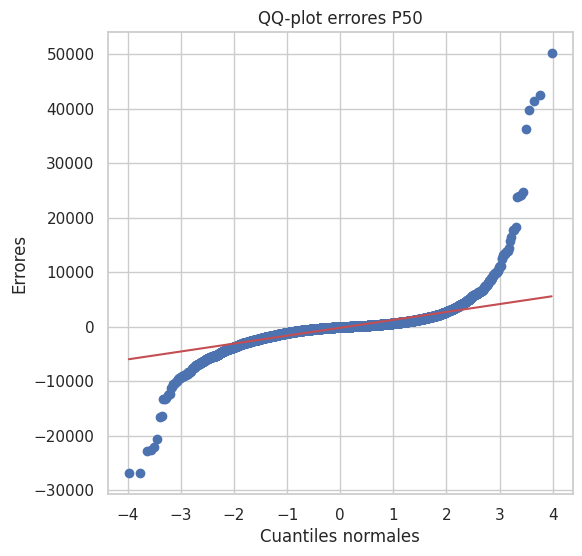

In [37]:
# QQ-plot de una muestra de residuos contra la normal (colas pesadas se alejan de la recta).
fig,ax=plt.subplots(figsize=(6,6))
stats.probplot(res[:20000],plot=ax)
ax.set(title="QQ-plot errores P50",xlabel="Cuantiles normales",ylabel="Errores")
plt.show()

### 4.6 ARCH

H₀ homocedasticidad.

El test ARCH LM detecta heterocedasticidad (volatilidad variable en el tiempo). En demanda con estacionalidad y promociones es frecuente rechazar H₀: la incertidumbre no es constante y los intervalos deberían adaptarse.

In [38]:
# Test ARCH LM (muestra 10000, 12 rezagos): H0 = homocedasticidad.
a=het_arch(res[:10000],nlags=12)
pd.DataFrame([{"test":"ARCH LM","H0":"homocedasticidad","stat":a[0],"p_value":a[1],
               "decision":"rechazar H0" if a[1]<.05 else "no rechazar H0"}])

,test,H0,stat,p_value,decision
0,ARCH LM,homocedasticidad,1793.633024,0.0,rechazar H0


### 4.7 Drift simulado

Se aplica +20% al último tercio de actual. Es simulación de escenario, claramente separada de datos originales.

Para decidir cuándo reentrenar necesitamos saber cómo se comportan nuestras métricas ante un cambio. Esta celda **simula** un drift: multiplica por 1.2 el último tercio de los valores reales (escenario de crecimiento de demanda). Los datos originales no se modifican; `drifted` solo se usa para medir el impacto en MAE y en el detector PSI.

In [39]:
# Simulación de drift: +20% en el último tercio de las observaciones reales.
drifted=actual.copy()
drifted[int(.67*len(drifted)):]*=1.2
# MAE del baseline antes y después del drift; el % de cambio es el impacto del escenario.
base_mae=np.mean(abs(actual-baseline[.5]))
drift_mae=np.mean(abs(drifted-baseline[.5]))
print(base_mae,drift_mae,(drift_mae/base_mae-1)*100)

835.6628992061098 1067.902486790818 27.791061180930576


### 4.8 Detector de drift

PSI simple sobre error absoluto, bins train-reference.

PSI (Population Stability Index) cuantifica cuánto cambia la distribución de una variable entre una referencia y un periodo actual. Aquí lo aplicamos al error absoluto del baseline. Regla práctica: PSI < 0.1 = cambio leve; 0.1–0.25 = moderado (revisar); > 0.25 = drift severo (actuar). La celda siguiente define la función `psi` reutilizable con bins basados en los cuantiles de la referencia.

In [40]:
# PSI: mide el cambio de distribución entre referencia y actual (bins por cuantiles).
def psi(reference: np.ndarray,current: np.ndarray,bins: int=10)->float:
    edges=np.unique(np.quantile(reference,np.linspace(0,1,bins+1)))
    r=np.histogram(reference,bins=edges)[0]/len(reference)  # distribución de referencia
    q=np.histogram(current,bins=edges)[0]/len(current)      # distribución actual
    r=np.clip(r,1e-6,None); q=np.clip(q,1e-6,None)          # evita log(0)
    return float(np.sum((q-r)*np.log(q/r)))
# Referencia = primera mitad de errores; actual = segunda mitad (con drift simulado).
e0=abs(actual-baseline[.5]); e1=abs(drifted-baseline[.5])
print("PSI",psi(e0[:len(e0)//2],e1[len(e1)//2:]))

PSI 0.34883885465668


### 4.9 Pipeline de reentrenamiento

Reglas explícitas.

El monitoreo no es un dashboard decorativo: cada métrica tiene **umbral, acción y dueño**. La tabla siguiente define las reglas operativas: MAE de drift (>25% → investigar/reentrenar), cobertura P10–P90 (fuera de 0.75–0.85 → recalibrar), PSI de errores (>0.25 → investigar segmentos) y frescura de datos (más de un periodo esperado → detener scoring). El dueño del proceso es el *Forecasting course team* (ver Model Card).

En un despliegue real conviene sumar a estas reglas la *proporción de series con cobertura fuera de rango* y la antigüedad del último reentrenamiento como señales agregadas: una caída sostenida en esa proporción es tan accionable como el drift de una serie individual.

In [41]:
# Reglas de monitoreo: métrica -> umbral -> acción. Umbrales explícitos para decidir.
monitoring=pd.DataFrame({
    "metric":["MAE drift","coverage P10-P90","PSI errors","data freshness"],
    "threshold":[">25% vs reference","outside 0.75–0.85",">0.25",">1 expected period"],
    "action":["investigate/retrain","recalibrate","investigate segments","halt scoring"]})
monitoring

,metric,threshold,action
0,MAE drift,>25% vs reference,investigate/retrain
1,coverage P10-P90,outside 0.75–0.85,recalibrate
2,PSI errors,>0.25,investigate segments
3,data freshness,>1 expected period,halt scoring


### 4.10 Model Card

Resumen del baseline seleccionado por robustez y alcance completo.

La Model Card documenta el modelo que pasa a producción: el **baseline empírico** (cuantiles de errores estacionales), elegido por robustez y alcance (cubre las 1,428 series, sin dependencias externas). Incluye métricas verificadas del holdout, owner, criterio de reentrenamiento y limitaciones. Una Model Card es el artefacto que permite a cualquier persona —no solo a quien entrenó el modelo— operarlo con seguridad.

In [42]:
# Model Card del modelo en producción: transparencia sobre datos, métricas, owner y retrain.
model_card={
    "name":"Empirical Seasonal-Error Quantiles",
    "version":"1.0",
    "data":"M3 Monthly 1428 series",
    "horizon":18,
    "outputs":"P10/P25/P50/P75/P90",
    "intended_use":"benchmark and teaching",
    "limitations":"no exogenous variables; empirical tails; not causal",
    "metrics":prob_metrics(actual,baseline),   # métricas verificadas del holdout
    "owner":"Forecasting course team",         # dueño responsable
    "retrain":"on new complete monthly cycle after drift review"}  # criterio de reentrenamiento
print(json.dumps(model_card,indent=2))

{
  "name": "Empirical Seasonal-Error Quantiles",
  "version": "1.0",
  "data": "M3 Monthly 1428 series",
  "horizon": 18,
  "outputs": "P10/P25/P50/P75/P90",
  "intended_use": "benchmark and teaching",
  "limitations": "no exogenous variables; empirical tails; not causal",
  "metrics": {
    "pinball_0.1": 231.14290856858557,
    "pinball_0.25": 356.1401235068137,
    "pinball_0.5": 417.8314496030549,
    "pinball_0.75": 346.219898204287,
    "pinball_0.9": 217.11243973984585,
    "CRPS_approx": 627.3787278490348,
    "coverage_80": 0.6992685963274199,
    "width_80": 2152.5616623224
  },
  "owner": "Forecasting course team",
  "retrain": "on new complete monthly cycle after drift review"
}


## 5. Lecciones metodológicas

1. Un split estándar permite comparabilidad.  
2. Pinball mide cuantiles; cobertura y ancho evalúan calibración/sharpness.  
3. CRPS aquí es aproximación por cinco cuantiles, no integral exacta.  
4. Quantile LightGBM puede cruzar cuantiles; se aplicó ordenamiento post hoc.  
5. MLOps requiere umbrales, owners y acciones, no solo dashboards.  
6. No se reportan resultados DeepAR no ejecutados.

**Lectura de resultados.** En los outputs del notebook, LightGBM cuantílico obtuvo cobertura P10–P90 de 0.7887 y CRPS aproximado de 356.27 (mejor calibración que el baseline, 0.6993 y 627.38, y que LocalTrend200, 0.4492 y 1121.37), aunque el modelo seleccionado por decisión ejecutiva fue el baseline empírico por robustez y alcance. La lección de negocio: la mejor métrica no siempre es la mejor decisión operativa si el modelo añade complejidad sin un proceso de monitoreo que la sostenga.

> **Lo que este análisis NO puede afirmar:** que LightGBMQuantile será superior en cualquier dominio o dataset; que la cobertura global garantiza calibración uniforme en todas las series; que los intervalos seguirán siendo válidos si cambia el régimen de la demanda; ni que DeepAR habría superado al baseline, porque no fue ejecutado.

> **Regla de decisión:** si LightGBMQuantile mantiene cobertura cercana al nivel nominal y mejora pinball/CRPS frente al baseline, es candidato principal; si la cobertura cae de forma sostenida, usar recalibración o volver a EmpiricalNaive como *fallback* robusto; no promover un modelo solo por complejidad si no mejora calibración y *sharpness* frente a una alternativa simple.

## 6. Ejercicios propuestos

1. Calibre cuantiles por conformalización.  
2. Use más niveles para aproximar CRPS.  
3. Compare cobertura por longitud/dominio si obtiene metadatos.  
4. Implemente DeepAR con dependencia opcional.  
5. Construya CI que bloquee promociones por pérdida de cobertura.

**Pausa final.** ¿Respondió ya la pregunta guía? Con los resultados verificados: un intervalo estrecho pero descalibrado (p. ej., cobertura lejos del 80% nominal) es peor que uno ancho pero calibrado, porque la planificación dimensiona holguras a partir de la cobertura real. Si no puede verificar la cobertura, ningún intervalo —por estrecho que sea— es fiable.

**Checklist de reproducibilidad**

Antes de dar por buena esta semana, verificar que se cumple todo lo siguiente:

- [ ] Semilla fija (`SEED=42`) al inicio y misma versión de dependencias congeladas.
- [ ] Contrato de datos: 167,562 × 3 y 1,428 series (aserciones de la Sección 0).
- [ ] Partición temporal sin leakage: H=18 meses por serie, sin solapamiento train/test (Checkpoint).
- [ ] Mismas métricas (pinball, CRPS aproximado, cobertura, ancho) para todos los modelos.
- [ ] Umbrales de monitoreo con dueño y acción definidos (MAE drift, cobertura, PSI, frescura).
- [ ] Model Card actualizada con métricas del holdout, owner y criterio de reentrenamiento.
- [ ] Ningún resultado de modelo no ejecutado (DeepAR) en tablas comparativas.

In [43]:
# Cierre: resumen de la comparación y cobertura del modelo seleccionado.
print("Notebook 8 completado.")
print(score)
print("Baseline coverage:",model_card["metrics"]["coverage_80"])

Notebook 8 completado.
                      n  pinball_0.1  pinball_0.25  pinball_0.5  pinball_0.75  \
model                                                                           
EmpiricalNaive    25704   231.142909    356.140124   417.831450    346.219898   
LightGBMQuantile  25704   114.203701    196.096017   246.755041    207.755312   
LocalTrend200      3600   436.196653    646.805597   795.721729    578.027492   

                  pinball_0.9  CRPS_approx  coverage_80     width_80  
model                                                                 
EmpiricalNaive     217.112440   627.378728     0.699269  2152.561662  
LightGBMQuantile   125.865962   356.270414     0.788749  1547.855547  
LocalTrend200      346.672434  1121.369562     0.449167  3081.467976  
Baseline coverage: 0.6992685963274199


## Resumen global del curso

| Semana | Dataset | Split usado | Modelo principal | Métrica clave | Lección metodológica |
|---:|---|---|---|---|---|
| 1 | Metro Traffic | Temporal 80/20 | Seasonal Naive 168 | MASE | El orden temporal importa; random split filtra futuro. |
| 2 | Appliances Energy | 70/15/15 | ARIMA/ETS | MASE | Validation selecciona hiperparámetros; test se usa una vez. |
| 3 | Beijing PM2.5 | Rolling-origin, 3 folds | SARIMAX | MAE | Exógenas ayudan solo si existen en inferencia y son estables. |
| 4 | Bike Sharing | Walk-forward + embargo 24 h | LightGBM | MASE | Lags y rolling requieren `shift`; embargo reduce leakage. |
| 5 | Electricity | 296/74 series cold-start | LightGBM global | MASE macro | Sin contexto/metadatos no se recupera la escala del cliente nuevo. |
| 6 | OPSD Germany | Ventanas móviles de 7 días | LightGBM/LSTM | MASE | Deep learning debe justificar coste frente a baselines fuertes. |
| 7 | PeMS-SF | 770/193 sensores | TFT-like compacto | MAE | Transferencia por sensor no equivale a causalidad espacial. |
| 8 | M3 Monthly | Holdout oficial de 18 meses | LightGBM cuantílico | CRPS aproximado y cobertura | Forecast probabilístico exige calibración y monitoreo. |

Los resultados pertenecen a los protocolos ejecutados en estos notebooks. No constituyen rankings universales entre familias de modelos.